# Forecasting Diaper Demand

Brendan Reed  
12/9/2025

## 1. Imports

### Import Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

### Import Data

In [ ]:
df = pd.read_csv("data/diapers.csv")

df.head()

,Timestamp,BRANCH,ZIP CODE,SIZE,# PACKS,SIZE.1,# PACKS.1,SIZE.2,# PACKS.2,TOTAL,DATE,MONTH,YEAR,DAY,WEEKDAY
0,9/7/2021 0:00:00,GG,63011,1,3.0,NaN,NaN,NaN,NaN,3,September 2021,September,2021,7,Tue
1,9/7/2021 0:00:00,GG,63011,3T,2.0,NaN,NaN,NaN,NaN,2,September 2021,September,2021,7,Tue
2,9/14/2021 0:00:00,GG,63118,5,2.0,NaN,NaN,NaN,NaN,2,September 2021,September,2021,14,Tue
3,9/14/2021 0:00:00,GG,63118,6,2.0,NaN,NaN,NaN,NaN,2,September 2021,September,2021,14,Tue
4,9/14/2021 0:00:00,GG,63125,5,2.0,NaN,NaN,NaN,NaN,2,September 2021,September,2021,14,Tue


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59425 entries, 0 to 59424
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  50120 non-null  object 
 1   BRANCH     50117 non-null  object 
 2   ZIP CODE   50113 non-null  object 
 3   SIZE       49967 non-null  object 
 4   # PACKS    50090 non-null  float64
 5   SIZE.1     7687 non-null   object 
 6   # PACKS.1  7595 non-null   float64
 7   SIZE.2     1648 non-null   object 
 8   # PACKS.2  2491 non-null   float64
 9   TOTAL      59425 non-null  int64  
 10  DATE       59425 non-null  object 
 11  MONTH      50120 non-null  object 
 12  YEAR       50120 non-null  object 
 13  DAY        50120 non-null  object 
 14  WEEKDAY    50120 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 6.8+ MB


## 2. Cleaning Data

Choose only desired columns

In [ ]:
df = df[[
    'Timestamp', 'BRANCH', 'ZIP CODE', 'SIZE', '# PACKS', 'SIZE.1',
    '# PACKS.1', 'SIZE.2', '# PACKS.2', 'TOTAL'
]]

Make all column names lower case

In [ ]:
df.columns = [item.lower() for item in list(df.columns)]

Filter to only Weber Road

In [ ]:
df = df[df['branch'] == "WR"]

Create a row for each pair of sizes and # packs

In [ ]:
size_cols = ["size", "size.1", "size.2"]
pack_cols = ["# packs", "# packs.1", "# packs.2"]

pieces = []

for i in range(3):  # force 3 iterations
    temp = df[["timestamp", "branch", "zip code"]].copy()
    temp["size"] = df[size_cols[i]]
    temp["# packs"] = df[pack_cols[i]]
    pieces.append(temp)

df = pd.concat(pieces, ignore_index=True)


Drop rows where both size and # packs is NA

In [ ]:
df = df.dropna(subset=["size", "# packs"], how="all")

Check for missing values

In [ ]:
pd.DataFrame({
    "NaN Count": df.isna().sum(),
    "Total Rows": len(df),
    "Percent NaN": df.isna().mean() * 100
})


,NaN Count,Total Rows,Percent NaN
timestamp,0,12506,0.000000
branch,0,12506,0.000000
zip code,4,12506,0.031985
size,444,12506,3.550296
# packs,25,12506,0.199904


Size is missing for 444 rows, which we will need to address. For now, I will leave missing values and see how prevalent they are across different months.

See unique sizes

In [ ]:
df["size"].unique()

array(['6', '3', '4', 'n', '2', '3t', '1', '5', 'N', '3T', '2T', '2t',
       'adult', '4t', '4T', nan, '7'], dtype=object)

Some sizes have duplicates or are not valid.  
Fixes: 
- 'n' and 'N' need to be combined
- 2t and 2T need to be combined for pullups (same with 3t/3T and 4t/4T)
- size 7 needs to be added to nan (we do not give out size 7)

In [ ]:
# cast all sizes to strings
df['size'] = df['size'].astype(str)

# make all letters in df["size"] upper case
df["size"] = [x.upper() for x in df["size"]]

# replace size 7 with "Not a Number"
df["size"] = df["size"].replace("7", "NAN")

# Replace real NaN in size with a category name
df['size_cat'] = df['size'].astype('object').fillna('NAN')

Create date and month columns

In [ ]:
# convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# create month column
df['month'] = df['timestamp'].dt.to_period('M')

# create date column
df['date'] = pd.to_datetime(df['timestamp']).dt.date

# remove timestamp column
df = df.drop('timestamp', axis=1)


## 3. Exploratory Analysis

### 3.1 Monthly Totals for Each Size

Create pivot table to see totals for each size by month

In [ ]:
# Build pivot table
table = df.pivot_table(
    index='month',
    columns='size_cat',
    values='# packs',
    aggfunc='sum',
    fill_value=0,
    dropna=False
)

In [ ]:
table['total'] = table.sum(axis=1)

# Total without NAN
table['adj total'] = table['total'] - table['NAN'] 

# month2 must have different name than month because month belongs to index
table['month2'] = table.index.month

table['year'] = table.index.year

# Total without NAN, pull-ups, and adult
table['adj total 2'] = table['total'] - (table['NAN'] + table['2T'] + table['3T'] + table['4T'] + table['ADULT'])

In [ ]:
table.head()

size_cat,1,2,2T,3,3T,4,4T,5,6,ADULT,N,NAN,total,adj total,month2,year,adj total 2
month,,,,,,,,,,,,,,,,,
1902-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,2.0,10,1902,2.0
2021-09,9.0,15.0,0.0,18.0,6.0,24.0,0.0,20.0,16.0,0.0,15.0,0.0,123.0,123.0,9,2021,117.0
2021-10,9.0,14.0,6.0,27.0,6.0,27.0,0.0,48.0,30.0,0.0,15.0,0.0,182.0,182.0,10,2021,170.0
2021-11,14.0,28.0,2.0,39.0,2.0,34.0,0.0,44.0,42.0,0.0,12.0,0.0,217.0,217.0,11,2021,213.0
2021-12,31.0,30.0,0.0,43.0,4.0,32.0,0.0,46.0,50.0,0.0,12.0,0.0,248.0,248.0,12,2021,244.0


In [ ]:
# filter to data from last 3 years
table_filtered = table[(table.index.year >=2023)].copy()

Drop December 2025 - incomplete data

In [ ]:
table_filtered = table_filtered.loc[table_filtered.index != '2025-12-01']

In [ ]:
# Convert PeriodIndex to Timestamp for plotting
table_filtered.index = table_filtered.index.to_timestamp()

In [ ]:
# create NAN proportions column
table_filtered["NAN/total"] = round(table_filtered["NAN"] / table_filtered["total"], 2)

### 3.2 Missing Values for Each Month

In [ ]:
table_filtered[table_filtered["NAN"] > 0].loc[:,["NAN","total","NAN/total"]]

size_cat,NAN,total,NAN/total
month,,,
2024-06-01,31.0,344.0,0.09
2024-07-01,40.0,348.0,0.11
2024-08-01,46.0,392.0,0.12
2024-09-01,31.0,340.0,0.09
2024-10-01,42.0,317.0,0.13
2024-11-01,24.0,263.0,0.09
2024-12-01,17.0,279.0,0.06
2025-01-01,19.0,270.0,0.07
2025-02-01,29.0,267.0,0.11


Rows for 2024-06-01 forward have missing values for size.

### 3.3 Graphing Monthly Totals for Each Size

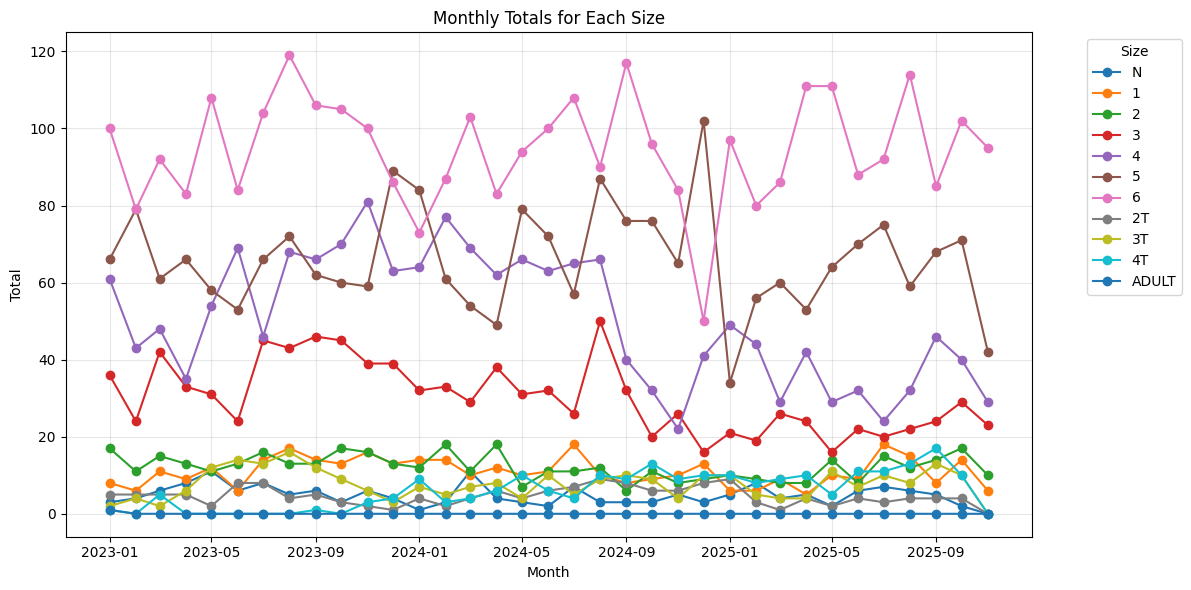

In [ ]:
size_cols = ['N', '1', '2', '3', '4', '5', '6', '2T', '3T', '4T', 'ADULT']

plt.figure(figsize=(12,6))

for col in size_cols:
    plt.plot(table_filtered.index, table_filtered[col], marker='o', label=col)

plt.title('Monthly Totals for Each Size')
plt.xlabel('Month')
plt.ylabel('Total')
plt.legend(title='Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The values for size 5 and 6 for 2024-12-01 are outliers. The dramatic increase in size 5 and decrease in size 6 is likely because the branch ran out of size 6, and so people chose size 5 instead.  

I will drop this row in future calculations.

In [ ]:
table_filtered.loc["2024-12-01",:].loc[["5","6"]].to_frame()

,2024-12-01
size_cat,
5,102.0
6,50.0


In [ ]:
table_filtered = table_filtered[table_filtered.index != "2024-12-01"]

### 3.4 Examining Proportions of Sizes

Create pivot table that shows proportions of each size to monthly totals

In [ ]:
size_cols = ['N', '1', '2', '3', '4', '5', '6', '2T', '3T', '4T', 'ADULT']


# Create a new DataFrame for proportions
prop_table = table_filtered[size_cols].div(table_filtered['adj total'], axis=0)

# Round to 2 decimals for readability
prop_table = prop_table.round(2)

<Figure size 1200x600 with 0 Axes>

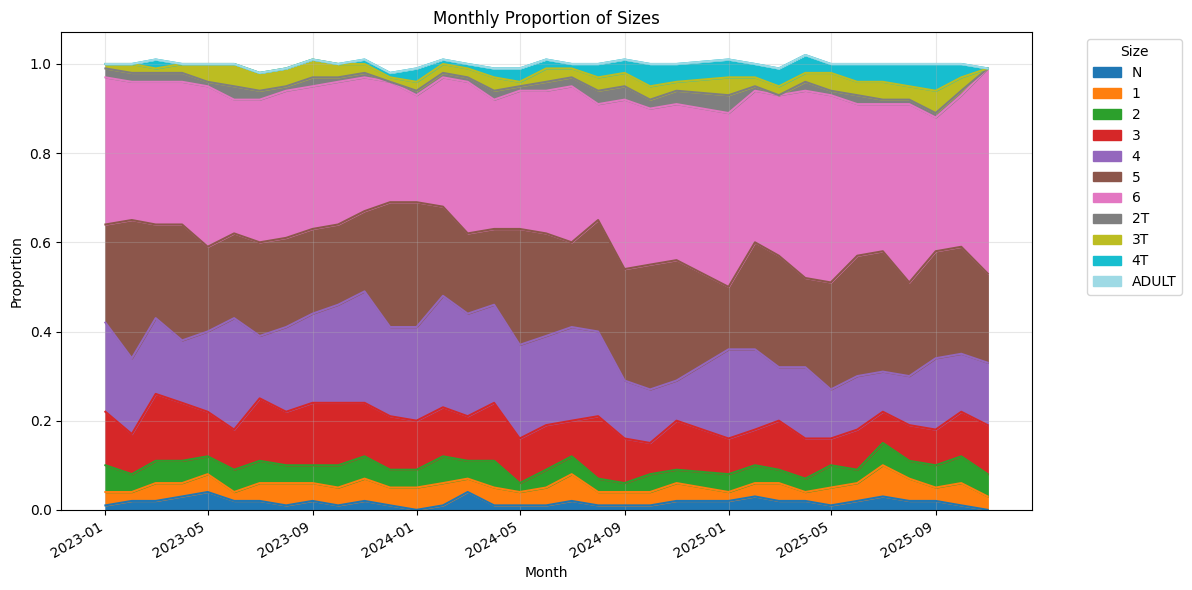

In [ ]:
plt.figure(figsize=(12,6))

# stacked area plot
prop_table.plot(kind='area', stacked=True, figsize=(12,6), cmap='tab20')

plt.title('Monthly Proportion of Sizes')
plt.xlabel('Month')
plt.ylabel('Proportion')
plt.legend(title='Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Total area (sum of proportions over all months)
total_area = prop_table[size_cols].sum()

total_area_percent = (total_area / total_area.sum())

Overall diaper size proportions from 2023 - 2025

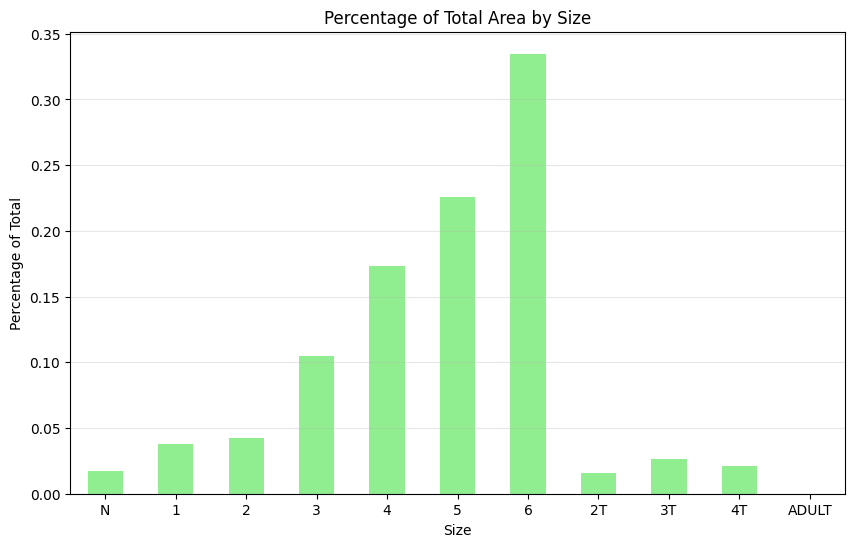

In [ ]:
total_area_percent.plot(kind='bar', figsize=(10,6), color='lightgreen')

plt.title('Percentage of Total Area by Size')
plt.xlabel('Size')
plt.ylabel('Percentage of Total')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()


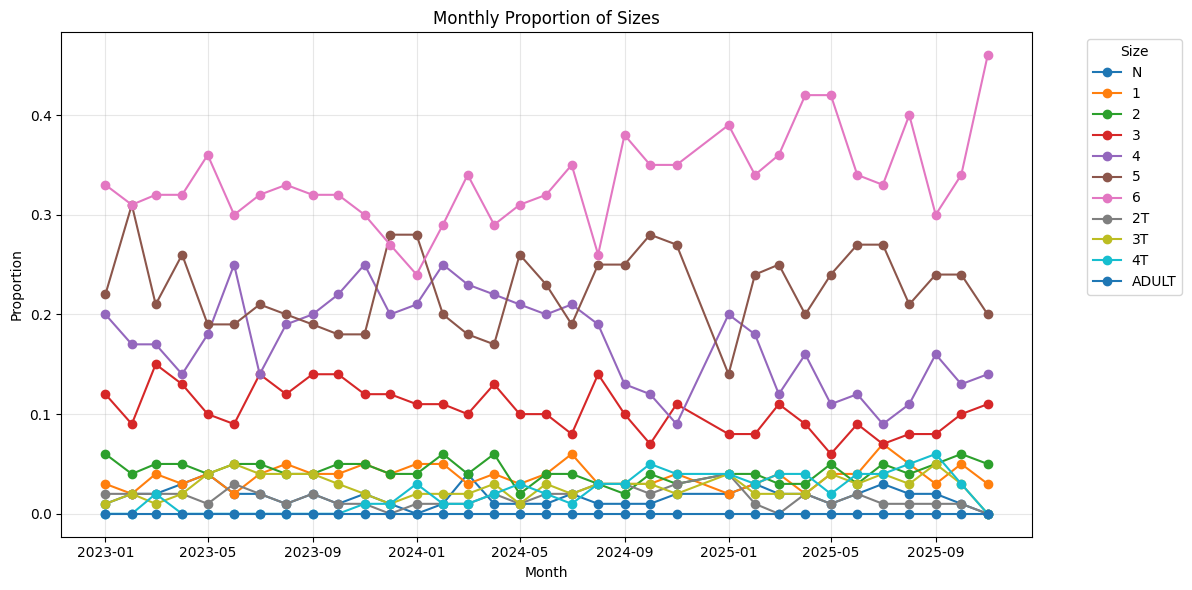

In [ ]:
plt.figure(figsize=(12,6))

for col in size_cols:
    plt.plot(prop_table.index, prop_table[col], marker='o', label=col)

plt.title('Monthly Proportion of Sizes')
plt.xlabel('Month')
plt.ylabel('Proportion')
plt.legend(title='Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
prop_table.loc[["2023-01-01", "2025-11-01"],:]

size_cat,N,1,2,3,4,5,6,2T,3T,4T,ADULT
month,,,,,,,,,,,
2023-01-01,0.01,0.03,0.06,0.12,0.20,0.22,0.33,0.02,0.01,0.0,0.0
2025-11-01,0.00,0.03,0.05,0.11,0.14,0.20,0.46,0.00,0.00,0.0,0.0


### Conclusions:
Size 6 has seen an upward trend proportionally, while other sizes have seen downward trends. At some points, less size 6 diapers are given out than size 5. This is probably due to running out of size 6 and people choosing size 5 instead. For the biggest size 6 dip in late 2024, the data point could be removed and interpolated, which could improve forcasting.

Options for generalizing proportions to the future:
- Look at total proportions for only the last 12 months
- Try to predict linear trends in proportions  

Use cases:
- Proportions could be used to fill in missing values for diaper sizes
- After total diapers distributed is predicted for future months, the total can be multiplied with proportions for sizes to predict number of sizes given out each month

## 4. Modeling

### 4.1 Use proportions to estimate missing data

For total diaper sizes for each month, we can multiply NaN totals with the proportion of each diaper size given out to estimate how many of each diaper size was not correctly recorded.

In [ ]:
size_cols = ['N', '1', '2', '3', '4', '5', '6', '2T', '3T', '4T', 'ADULT']

Only consider data from the last year.

In [ ]:
df_orig = table_filtered.loc['2024-12-01':'2025-11-01']

In [ ]:
proportions = df_orig[size_cols].div(df_orig['adj total'], axis=0).round(2)

In [ ]:
result = proportions.mul(df_orig['NAN'], axis=0)
result = result.round(0)

Adjusted Monthly Totals

In [ ]:
df_total = df_orig[size_cols] + result
df_total

size_cat,N,1,2,3,4,5,6,2T,3T,4T,ADULT
month,,,,,,,,,,,
2025-01-01,5.0,6.0,11.0,23.0,53.0,37.0,104.0,10.0,11.0,11.0,0.0
2025-02-01,9.0,7.0,10.0,21.0,49.0,63.0,90.0,3.0,6.0,9.0,0.0
2025-03-01,4.0,10.0,8.0,28.0,31.0,64.0,91.0,1.0,4.0,10.0,0.0
2025-04-01,6.0,6.0,9.0,27.0,46.0,59.0,123.0,5.0,5.0,11.0,0.0
2025-05-01,2.0,11.0,15.0,18.0,32.0,70.0,122.0,2.0,12.0,6.0,0.0
2025-06-01,6.0,10.0,9.0,24.0,34.0,75.0,94.0,4.0,8.0,12.0,0.0
2025-07-01,8.0,20.0,16.0,22.0,26.0,81.0,99.0,3.0,11.0,12.0,0.0
2025-08-01,7.0,16.0,13.0,24.0,35.0,65.0,126.0,4.0,9.0,14.0,0.0
2025-09-01,6.0,9.0,15.0,26.0,50.0,74.0,93.0,4.0,14.0,19.0,0.0


### 4.2 Diaper Total Trends

Looks at trends for total number of diapers distributed each month.

In [ ]:
totals_by_month = table_filtered.pivot_table(
    index='month2',
    columns='year',
    values='total',
    aggfunc='sum'
)

totals_by_month.loc[12,2025] = np.nan

In [ ]:
totals_by_month
pivot = totals_by_month
pivot

year,2023,2024,2025
month2,,,
1,300.0,300.0,270.0
2,255.0,303.0,267.0
3,287.0,302.0,250.0
4,258.0,286.0,294.0
5,299.0,308.0,290.0
6,277.0,344.0,275.0
7,320.0,348.0,297.0
8,357.0,392.0,314.0
9,331.0,340.0,311.0


Graph monthly totals by year to compare trends

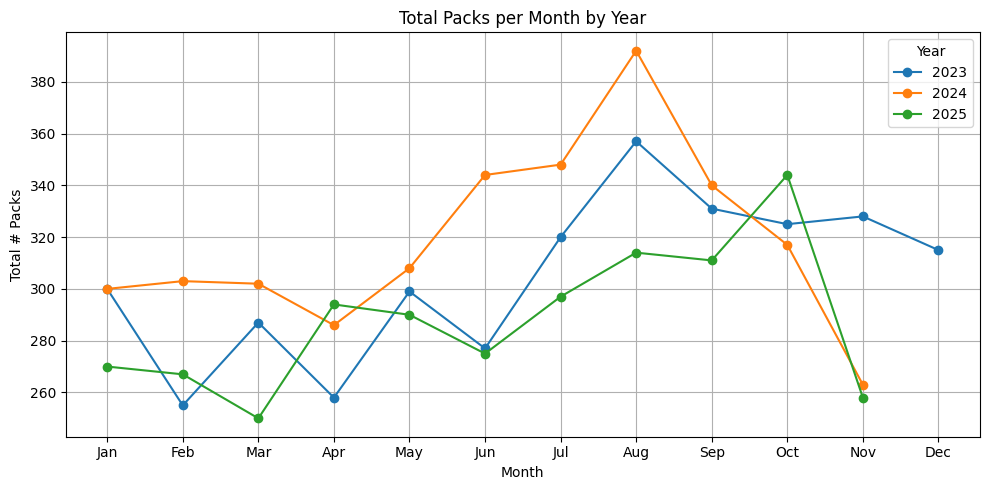

In [ ]:
plt.figure(figsize=(10,5))
for year in totals_by_month.columns:
    plt.plot(totals_by_month.index, totals_by_month[year], marker='o', label=str(year))

plt.xlabel("Month")
plt.ylabel("Total # Packs")
plt.title("Total Packs per Month by Year")
plt.xticks(ticks=range(1,13), labels=[
    "Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"
])
plt.legend(title="Year")
plt.grid(True)
plt.tight_layout()
plt.show()


Conclusion: 2023, 2024, and 2025 follow similar seasonal trends. Totals increase in summer and decrease in winter.

### 4.3 Modeling Total Diapers per Month

In [ ]:
# filter df to last 3 years
filtered = df[df["month"] >= "2023-01"]

In [ ]:
# create pivot table
pivot = pd.pivot_table(filtered, values="# packs", index='month',aggfunc='sum')

# drop 2025-12 nan since it represents incomplete data
pivot = pivot.drop("2025-12")

In [ ]:
# create series for Holt-Winters model
ts = pivot["# packs"]

Using Holt-Winters model for seasonal time-series estimation.

Deciding between Additive and Multiplicative:

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Additive Holt-Winters
model_add = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=12).fit()

# Multiplicative Holt-Winters
model_mul = ExponentialSmoothing(ts, trend='add', seasonal='mul', seasonal_periods=12).fit()

print("Additive AIC:", model_add.aic)
print("Multiplicative AIC:", model_mul.aic)

Additive AIC: 238.25818808260982
Multiplicative AIC: 237.5093791852088


Conclusion: The multiplicative AIC is lower, so we will use the seasonal multiplicative model.

In [ ]:
ts.index = ts.index.to_timestamp()

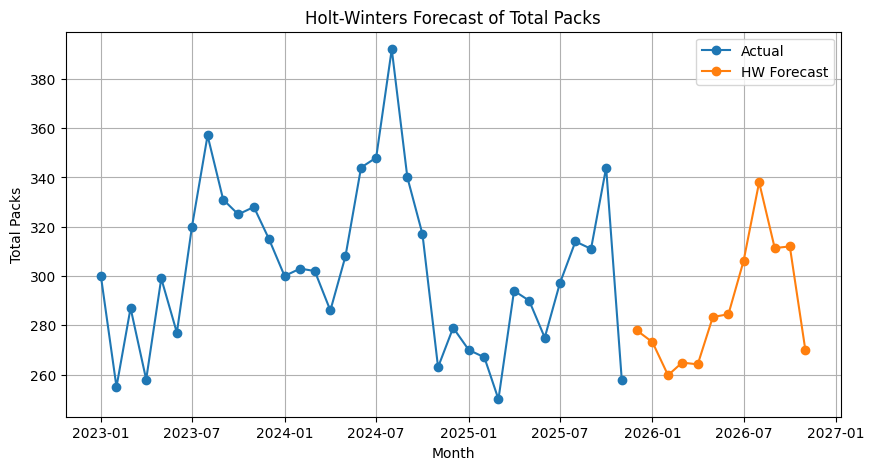

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# Fit Holt-Winters seasonal model (monthly data, yearly seasonality)
hw_model = ExponentialSmoothing(ts, seasonal='mul', seasonal_periods=12)
hw_fit = hw_model.fit()

# create index
forecast_steps = 12

future_index = pd.date_range(
    start=ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq="MS"
)

# Forecast next 12 months
hw_forecast = pd.Series(
    hw_fit.forecast(forecast_steps),
    index=future_index
)

# Plot
plt.figure(figsize=(10,5))
plt.plot(ts.index, ts, label='Actual', marker='o')
plt.plot(hw_forecast.index, hw_forecast, label='HW Forecast', marker='o')
plt.title('Holt-Winters Forecast of Total Packs')
plt.xlabel('Month')
plt.ylabel('Total Packs')
plt.legend()
plt.grid(True)
plt.show()

# plt.plot(y.index, y, label="Actual")
# plt.plot(forecast.index, forecast, label="HW Forecast")
# plt.legend()
# plt.show()


**Conclusion**: The Holt-Winters model captures a general downward trend in distribution, while also capturing the seasonal pattern.

## 5. Examining Storage

### 5.1 Create storage table with proportions

In [ ]:
# import data
storage = pd.read_csv("data/storage.csv", index_col=0)

# select sizes 1 - 6
storage = storage.loc["1":"6"]

# create proportion column
storage["Proportion"] = round(storage["Total"] / sum(storage["Total"]), 2)

storage

,Total,Proportion
Size,,
1,63,0.14
2,63,0.14
3,90,0.20
4,60,0.13
5,60,0.13
6,120,0.26


### 5.2 Create table showing average sizes given out monthly

In [ ]:
df_total
month_avg = np.ceil(df_total.mean()).to_frame()

,0
size_cat,
N,5.0
1,11.0
2,13.0
3,25.0
4,40.0
5,66.0
6,108.0
2T,4.0
3T,9.0


### 5.3 Create table with new recommended stock according to average monthly proportions

In [ ]:
df_combined = pd.concat([storage, month_avg], axis=1)

df_combined["Shelf"] = month_avg.index
df_combined = df_combined.set_index("Shelf")

df_combined["Recommended New Totals"] = round(df_combined["Proportion of Total"] * df_combined["Total"].sum(), 0)
df_combined['Recommended New Totals'] = [math.ceil(x) for x in df_combined['Recommended New Totals']]

df_combined.columns = ["Current Storage", "Current Proportion", "Avg. Per Month", "Avg. Proportion", "Rec. New Storage"]

df_combined

NameError: name 'month_avg' is not defined

### 5.4 Compare current storage to new suggestion

In [ ]:
compare = df_combined.loc[:, ["Current Proportion", "Current Storage", "Avg. Proportion", "Rec. New Storage"]]
compare

,Current Proportion,Current Storage,Avg. Proportion,Rec. New Storage
Shelf,,,,
1,0.14,63,0.04,18
2,0.14,63,0.05,23
3,0.20,90,0.10,46
4,0.13,60,0.15,68
5,0.13,60,0.25,114
6,0.26,120,0.41,187


### 5.5 Storage Changes

In [ ]:
changes = compare.loc[:,["Current Storage", "Rec. New Storage"]]
changes["Change"] = changes["Rec. New Storage"] - changes["Current Storage"]
changes["% Change"] = round(changes["Change"] / changes["Current Storage"], 2)

changes

,Current Storage,Rec. New Storage,Change,% Change
Shelf,,,,
1,63,18,-45,-0.71
2,63,23,-40,-0.63
3,90,46,-44,-0.49
4,60,68,8,0.13
5,60,114,54,0.90
6,120,187,67,0.56


### 5.6 How long would stock last on average?

In [ ]:
# table for how many months we could last with our shelves fully stocked
current = df_combined["Current Storage"]
current_months = round(df_combined["Current Storage"] / df_combined['Avg. Per Month'], 1)
new = df_combined["Rec. New Storage"]
new_months = round(df_combined["Rec. New Storage"] / df_combined['Avg. Per Month'], 1)

stock = pd.DataFrame({
    'storage': current,
    'current_months': current_months,
    'new storage': new,
    'new_months': new_months
})

stock

,storage,current_months,new storage,new_months
Shelf,,,,
1,63,5.7,18,1.6
2,63,4.8,23,1.8
3,90,3.6,46,1.8
4,60,1.5,68,1.7
5,60,0.9,114,1.7
6,120,1.1,187,1.7


### 5.7 Should some of the smaller sizes have more stock to act as a buffer?

Is there a chance that having low stock of smaller sizes could lead to us running out?

In [ ]:
sizes = ["1", "2", "3", "4", "5", "6"]

sizes_monthly = table_filtered[sizes]
sizes_monthly = sizes_monthly.loc["2025-01-01":"2025-11-01"]

Create boxplots to show monthly size distribution 

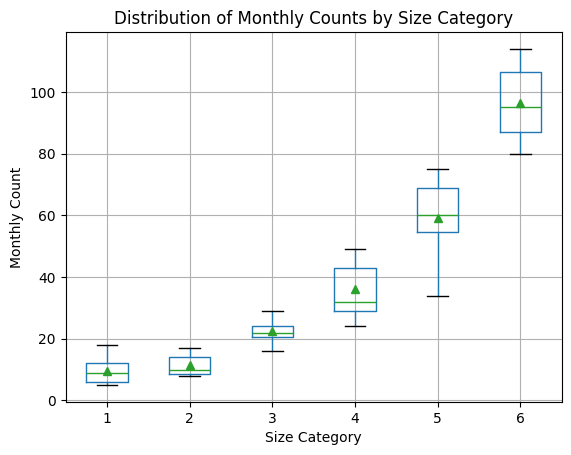

In [ ]:
sizes_monthly.boxplot(showmeans=True)
plt.xlabel("Size Category")
plt.ylabel("Monthly Count")
plt.title("Distribution of Monthly Counts by Size Category")
plt.show()

- Calculate difference between new storage amounts and max of each size given out
- Tells us if we would have ran out

In [ ]:
storage_performance = stock["new storage"].to_frame(name="new storage")
storage_performance["max in 2025"] = sizes_monthly.max()
storage_performance["over/under"] = storage_performance["new storage"] - storage_performance["max in 2025"]

storage_performance

,new storage,max in 2025,over/under
Shelf,,,
1,18,18.0,0.0
2,23,17.0,6.0
3,46,29.0,17.0
4,68,49.0,19.0
5,114,75.0,39.0
6,187,114.0,73.0


Size 1 would have ran through full stock in a month. Let's take a closer look at the distribution.

In [ ]:
sizes_monthly["1"]

month
2025-01-01     6.0
2025-02-01     6.0
2025-03-01     9.0
2025-04-01     5.0
2025-05-01    10.0
2025-06-01     9.0
2025-07-01    18.0
2025-08-01    15.0
2025-09-01     8.0
2025-10-01    14.0
2025-11-01     6.0
Name: 1, dtype: float64

Size 1 totals are usually less than 10, but it wouldn't hurt to increase the size from 18 to 20.

In [ ]:
df_combined

,Current Storage,Current Proportion,Avg. Per Month,Avg. Proportion,Rec. New Storage
Shelf,,,,,
1,63,0.14,11,0.04,18
2,63,0.14,13,0.05,23
3,90,0.20,25,0.10,46
4,60,0.13,40,0.15,68
5,60,0.13,66,0.25,114
6,120,0.26,108,0.41,187


## 6. Weekly Proportions

Look at weekly breakdowns

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [ ]:
df['week_of_month'] = 1 + (df['date'].dt.day - 1) // 7

In [ ]:
df['year'] = df['date'].dt.year
df['month_num'] = df['date'].dt.month

pivot = df.pivot_table(
    index=['year', 'month_num', 'week_of_month'],   # rows
    columns='size_cat',                              # size categories
    values='# packs',
    aggfunc='sum',
    fill_value=0
)


In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [ ]:
pivot_1yr = pivot.loc[(2025,1,1):(2025,11,5)].copy()
pivot_1yr["TOTAL"] = pivot_1yr.sum(axis=1)

In [ ]:
# Assume your pivot_1yr table is called pivot_1yr
import pandas as pd

# Compute monthly totals of the TOTAL column
monthly_totals = pivot_1yr.groupby(level=['year','month_num'])['TOTAL'].transform('sum')

# Divide all size columns by monthly total to get proportion
size_columns = ['1','2','2T','3','3T','4','4T','5','6','ADULT','N','NAN']

# Create a new table with proportions
pivot_1yr_prop = pivot_1yr.copy()

# Optional: also include proportion of total per week
pivot_1yr_prop['TOTAL_prop'] = round(pivot_1yr['TOTAL'] / monthly_totals,2)




In [ ]:
pivot_1yr_prop

size_cat                        1    2   2T     3   3T     4   4T     5     6  \
year month_num week_of_month                                                    
2025 1         1              0.0  2.0  2.0   2.0  2.0   4.0  2.0  10.0  24.0   
               2              3.0  3.0  0.0   2.0  0.0  11.0  2.0  12.0  35.0   
               3              1.0  0.0  6.0   7.0  0.0  14.0  1.0   1.0   5.0   
               4              0.0  1.0  1.0   6.0  8.0  12.0  5.0   4.0  13.0   
               5              2.0  4.0  0.0   4.0  0.0   8.0  0.0   7.0  20.0   
     2         1              2.0  2.0  1.0   5.0  2.0  24.0  4.0  24.0  32.0   
               2              1.0  1.0  1.0   4.0  2.0   5.0  1.0  13.0  10.0   
               3              2.0  3.0  1.0   3.0  0.0   6.0  1.0   6.0  14.0   
               4              1.0  3.0  0.0   7.0  1.0   9.0  2.0  13.0  24.0   
     3         1              3.0  2.0  0.0  11.0  1.0  11.0  3.0  17.0  31.0   
               2              3.0  1.0  1.0   8.0  2.0   8.0  0.0  14.0  16.0   
               3              2.0  2.0  0.0   2.0  0.0   2.0  4.0  14.0  17.0   
               4              1.0  2.0  0.0   3.0  1.0   6.0  2.0  12.0  16.0   
               5              0.0  1.0  0.0   2.0  0.0   2.0  0.0   3.0   6.0   
     4         1              3.0  1.0  2.0   5.0  1.0   8.0  3.0  22.0  31.0   
               2              2.0  2.0  0.0  10.0  0.0  15.0  2.0  12.0  39.0   
               3              0.0  3.0  1.0   7.0  0.0   4.0  3.0   3.0  15.0   
               4              0.0  2.0  1.0   1.0  3.0   9.0  2.0   9.0  14.0   
               5              0.0  0.0  0.0   1.0  0.0   6.0  0.0   7.0  12.0   
     5         1              4.0  0.0  1.0   3.0  6.0   6.0  3.0  22.0  39.0   
               2              1.0  7.0  0.0   4.0  5.0  12.0  1.0  27.0  25.0   
               3              1.0  1.0  0.0   6.0  0.0   7.0  0.0   6.0  24.0   
               4              1.0  1.0  1.0   0.0  0.0   2.0  1.0   4.0  11.0   
               5              3.0  5.0  0.0   3.0  0.0   2.0  0.0   5.0  12.0   
     6         1              2.0  4.0  2.0   7.0  1.0   9.0  6.0  28.0  34.0   
               2              6.0  2.0  0.0   3.0  4.0   9.0  2.0  21.0  23.0   
               3              0.0  0.0  1.0   5.0  0.0   7.0  1.0  10.0   9.0   
               4              1.0  2.0  0.0   6.0  2.0   5.0  2.0   9.0  16.0   
               5              0.0  0.0  1.0   1.0  0.0   2.0  0.0   2.0   6.0   
     7         1              3.0  6.0  2.0   6.0  3.0   2.0  3.0  23.0  22.0   
               2              2.0  2.0  0.0   4.0  3.0  10.0  6.0  21.0  39.0   
               3              0.0  1.0  0.0   3.0  1.0   6.0  0.0  13.0  13.0   
               4              6.0  6.0  0.0   2.0  1.0   4.0  2.0  11.0  12.0   
               5              7.0  0.0  1.0   5.0  2.0   2.0  0.0   7.0   6.0   
     8         1              5.0  3.0  0.0   7.0  1.0   5.0  7.0  20.0  48.0   
               2              3.0  0.0  2.0   6.0  2.0   7.0  5.0  13.0  17.0   
               3              5.0  3.0  1.0   2.0  3.0   8.0  0.0  12.0  18.0   
               4              2.0  5.0  1.0   4.0  2.0  11.0  1.0  12.0  25.0   
               5              0.0  1.0  0.0   3.0  0.0   1.0  0.0   2.0   6.0   
     9         1              5.0  2.0  2.0   8.0  5.0  12.0  4.0  19.0  30.0   
               2              0.0  5.0  1.0   4.0  2.0  15.0  7.0  16.0  25.0   
               3              1.0  4.0  0.0   5.0  4.0  12.0  4.0  15.0  11.0   
               4              1.0  3.0  1.0   4.0  0.0   5.0  2.0  15.0  11.0   
               5              1.0  0.0  0.0   3.0  2.0   2.0  0.0   3.0   8.0   
     10        1              4.0  6.0  3.0   6.0  6.0   9.0  6.0  24.0  33.0   
               2              3.0  3.0  1.0   9.0  2.0  11.0  4.0   6.0  25.0   
               3              6.0  2.0  0.0   5.0  2.0   8.0  0.0  23.0  20.0   
               4              1

In [ ]:
s = pivot_1yr_prop['TOTAL_prop']
temp_df = s.reset_index()
temp_df.columns = ['year', 'month_num', 'week_of_month', 'value']  # rename columns
temp_df['month_part'] = temp_df['week_of_month'].apply(lambda x: 1 if x in [1, 2] else 2)

In [ ]:
pivot_month_halves = pd.pivot_table(
    temp_df,
    index=['year', 'month_num', 'month_part'],
    values='value',
    aggfunc='sum'
).reset_index()

pivot_month_halves.head()

,year,month_num,month_part,value
0,2025,1,1,0.47
1,2025,1,2,0.53
2,2025,2,1,0.59
3,2025,2,2,0.40
4,2025,3,1,0.55


In [ ]:
pivot_month_halves.groupby("month_part")["value"].agg(["mean", "std"])


,mean,std
month_part,,
1,0.580000,0.073485
2,0.415455,0.073806


## 7. Forecasting Distribution by Size

Using ratios...

In [ ]:
proportions

# Total area (sum of proportions over all months)
total_area = proportions.sum()

total_area_percent = (total_area / total_area.sum())

In [ ]:
df_total_sum = df_total.sum(axis=1)

In [ ]:
result = []
for i in df_total_sum:
    row = []
    for j in total_area_percent:
        row.append(round(i * j,0))
    result.append(row)

In [ ]:
predicted_totals = pd.DataFrame(result, columns=df_total.columns, index=df_total.index)

In [ ]:
predicted_totals

size_cat,N,1,2,3,4,5,6,2T,3T,4T,ADULT
month,,,,,,,,,,,
2025-01-01,5.0,10.0,12.0,23.0,37.0,62.0,101.0,3.0,8.0,10.0,0.0
2025-02-01,5.0,10.0,11.0,23.0,37.0,61.0,99.0,3.0,8.0,9.0,0.0
2025-03-01,5.0,10.0,11.0,22.0,35.0,57.0,93.0,3.0,7.0,9.0,0.0
2025-04-01,5.0,11.0,13.0,26.0,41.0,67.0,111.0,4.0,9.0,11.0,0.0
2025-05-01,5.0,11.0,12.0,25.0,40.0,66.0,108.0,4.0,8.0,10.0,0.0
2025-06-01,5.0,11.0,12.0,24.0,38.0,63.0,103.0,4.0,8.0,10.0,0.0
2025-07-01,5.0,11.0,13.0,26.0,41.0,68.0,111.0,4.0,9.0,11.0,0.0
2025-08-01,6.0,12.0,13.0,27.0,43.0,71.0,117.0,4.0,9.0,11.0,0.0
2025-09-01,6.0,12.0,13.0,27.0,43.0,70.0,115.0,4.0,9.0,11.0,0.0


In [ ]:
performance = predicted_totals - df_total
performance

size_cat,N,1,2,3,4,5,6,2T,3T,4T,ADULT
month,,,,,,,,,,,
2025-01-01,0.0,4.0,1.0,0.0,-16.0,25.0,-3.0,-7.0,-3.0,-1.0,0.0
2025-02-01,-4.0,3.0,1.0,2.0,-12.0,-2.0,9.0,0.0,2.0,0.0,0.0
2025-03-01,1.0,0.0,3.0,-6.0,4.0,-7.0,2.0,2.0,3.0,-1.0,0.0
2025-04-01,-1.0,5.0,4.0,-1.0,-5.0,8.0,-12.0,-1.0,4.0,0.0,0.0
2025-05-01,3.0,0.0,-3.0,7.0,8.0,-4.0,-14.0,2.0,-4.0,4.0,0.0
2025-06-01,-1.0,1.0,3.0,0.0,4.0,-12.0,9.0,0.0,0.0,-2.0,0.0
2025-07-01,-3.0,-9.0,-3.0,4.0,15.0,-13.0,12.0,1.0,-2.0,-1.0,0.0
2025-08-01,-1.0,-4.0,0.0,3.0,8.0,6.0,-9.0,0.0,0.0,-3.0,0.0
2025-09-01,0.0,3.0,-2.0,1.0,-7.0,-4.0,22.0,0.0,-5.0,-8.0,0.0


Future analysis: Try stock - df_total to see how we would do during the month

## 8. Conclusion

Initial plan
- Reconfigure storage according to recommendations in Storage section
- Order enough diapers to fill stock

For future reordering:
- Order every 2 weeks
- Order to replenish what we have given out in the last 2 weeks

Questions
- How long after placing a diaper order does it arrive?`